In [4]:
!pip install datasets pandas matplotlib pyarrow transformers -q

README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=128) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Model loaded successfully.


Both `max_new_tokens` (=128) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

Experiment completed.
    id       prompt_type  true_answer  predicted_answer  is_correct
0    0         Zero-shot           18             120.0       False
1    0          Few-shot           18              24.0       False
2    0  Chain-of-Thought           18              50.0       False
3    1         Zero-shot            3               2.0       False
4    1          Few-shot            3             100.0       False
5    1  Chain-of-Thought            3               3.0        True
6    2         Zero-shot        70000           15000.0       False
7    2          Few-shot        70000           15000.0       False
8    2  Chain-of-Thought        70000             150.0       False
9    3         Zero-shot          540            1800.0       False
10   3          Few-shot          540             150.0       False
11   3  Chain-of-Thought          540               3.0       False
12   4         Zero-shot           20              10.0       False
13   4          Few-shot  

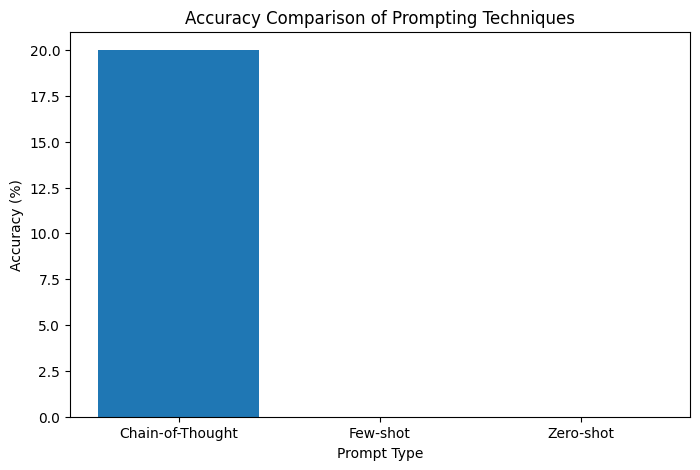

In [5]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import pipeline

# Load dataset
dataset = load_dataset("gsm8k", "main")
samples = dataset["test"].select(range(5))

print("Number of questions selected:", len(samples))
print("\nFirst sample:\n", samples[0])

# Load model
generator = pipeline(
    "text-generation",
    model="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    device_map="auto"
)

print("Model loaded successfully.")

# Prompt templates
def zero_shot_prompt(question):
    return f"""Solve the following math problem.
Give only the final answer.

Question: {question}
Answer:"""

def few_shot_prompt(question):
    return f"""Solve the following math problems.

Example 1:
Question: Ravi has 3 apples and buys 2 more. How many apples does he have?
Answer: 5

Example 2:
Question: There are 4 pencils in one box. If there are 3 boxes, how many pencils are there?
Answer: 12

Now solve:
Question: {question}
Answer:"""

def cot_prompt(question):
    return f"""Solve the following math problem step by step.
Then give the final answer clearly.

Question: {question}
Solution:"""

# Generate response
def get_response(prompt):
    output = generator(
        prompt,
        max_new_tokens=128,
        do_sample=False,   # deterministic
        pad_token_id=generator.tokenizer.eos_token_id,
        return_full_text=False  # FIX: cleaner output
    )
    return output[0]["generated_text"].strip()

# Extract number
def extract_number(text):
    if text is None:
        return None
    numbers = re.findall(r'-?\d+\.?\d*', text.replace(",", ""))
    return numbers[-1] if numbers else None

# Run experiment
results = []

for i, sample in enumerate(samples):
    question = sample["question"]
    true_answer_text = sample["answer"]
    true_answer = extract_number(true_answer_text)

    for prompt_type, prompt_func in [
        ("Zero-shot", zero_shot_prompt),
        ("Few-shot", few_shot_prompt),
        ("Chain-of-Thought", cot_prompt)
    ]:
        prompt = prompt_func(question)
        response = get_response(prompt)
        pred = extract_number(response)

        results.append({
            "id": i,
            "question": question,
            "prompt_type": prompt_type,
            "model_response": response,
            "true_answer": true_answer,
            "predicted_answer": pred
        })

print("Experiment completed.")

# DataFrame
df = pd.DataFrame(results)

# Convert to numeric for accurate comparison
df["true_answer"] = pd.to_numeric(df["true_answer"], errors="coerce")
df["predicted_answer"] = pd.to_numeric(df["predicted_answer"], errors="coerce")

# Accuracy check
df["is_correct"] = df["true_answer"] == df["predicted_answer"]

print(df[["id", "prompt_type", "true_answer", "predicted_answer", "is_correct"]])

# Accuracy table
accuracy_table = df.groupby("prompt_type")["is_correct"].mean() * 100
accuracy_table = accuracy_table.reset_index()
accuracy_table.columns = ["Prompt Type", "Accuracy (%)"]

print("\nAccuracy Table:\n", accuracy_table)

# Plot
plt.figure(figsize=(8, 5))
plt.bar(accuracy_table["Prompt Type"], accuracy_table["Accuracy (%)"])
plt.xlabel("Prompt Type")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison of Prompting Techniques")
plt.show()